In [1]:
import pandas as pd
import numpy as np
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple, Optional
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
import warnings
warnings.filterwarnings('ignore')

class CompleteSVR:
    """
    Advanced Support Vector Regression model with multiple training modes,
    comprehensive evaluation metrics, and visualization capabilities.
    """
    
    def __init__(self):
        self.model = None
        self.scaler_X = StandardScaler()
        self.scaler_y = StandardScaler()
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None
        self.feature_names = None
        self.original_feature_names = None
        self.target_name = None
        self.is_fitted = False
        self.training_mode = None
        self.best_params = None
        self.test_size = None
        self.random_state = None
        self.data_info = {}
        
    def load_data(self, csv_path: str, target_column: str, test_size: float = 0.2
                  
                  ,random_state: int = 42):
        """
        Load data from CSV file and prepare for training.
        
        Parameters:
        -----------
        csv_path : str
            Path to the CSV file
        target_column : str
            Name of the target column
        test_size : float, default=0.2
            Proportion of data to use for testing
        random_state : int, default=42
            Random state for reproducibility
        """
        # Load data
        self.data = pd.read_csv(csv_path).round(2)
        print(f"Data loaded successfully: {self.data.shape}")
        print(f"Columns: {list(self.data.columns)}")
        
        # Separate features and target
        self.X = self.data.drop(columns=[target_column])
        self.y = self.data[target_column]
        self.feature_names = list(self.X.columns)
        self.target_name = target_column
        self.original_feature_names = self.feature_names.copy()  # Keep original list
        
        # Split data
        self.test_size = test_size
        self.random_state = random_state
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            self.X, self.y, test_size=test_size, random_state=random_state
        )
        
        # Store data information
        self._store_data_info()
        
        print(f"Training set: {self.X_train.shape[0]} samples ({100*(1-test_size):.1f}%)")
        print(f"Test set: {self.X_test.shape[0]} samples ({100*test_size:.1f}%)")
        print(f"Features: {len(self.feature_names)}")
        print(f"Test size parameter: {test_size}")
        print(f"Random state: {random_state}")
        
    def _store_data_info(self):
        """Store comprehensive data information for later display."""
        self.data_info = {
            'total_samples': len(self.data),
            'train_samples': len(self.X_train),
            'test_samples': len(self.X_test),
            'train_percentage': 100 * len(self.X_train) / len(self.data),
            'test_percentage': 100 * len(self.X_test) / len(self.data),
            'n_features': len(self.feature_names),
            'target_stats': {
                'mean': self.y.mean(),
                'std': self.y.std(),
                'min': self.y.min(),
                'max': self.y.max()
            },
            'feature_stats': {
                'mean': self.X.mean().to_dict(),
                'std': self.X.std().to_dict(),
                'min': self.X.min().to_dict(),
                'max': self.X.max().to_dict()
            }
        }
        
    def show_data_info(self):
        """Display comprehensive information about data preprocessing and splits."""
        if not hasattr(self, 'data_info'):
            raise ValueError("Data must be loaded before showing data info!")
            
        print(f"\n📋 DATA PREPROCESSING INFORMATION")
        print("="*60)
        
        # Dataset split information
        print(f"🔄 DATASET SPLITS:")
        print(f"  Total samples:     {self.data_info['total_samples']:,}")
        print(f"  Training samples:  {self.data_info['train_samples']:,} ({self.data_info['train_percentage']:.1f}%)")
        print(f"  Test samples:      {self.data_info['test_samples']:,} ({self.data_info['test_percentage']:.1f}%)")
        print(f"  Test_size parameter: {self.test_size}")
        print(f"  Train_size parameter: {1-self.test_size}")
        print(f"  Random state:      {self.random_state}")
        
        # Feature information
        print(f"\n📊 FEATURES:")
        print(f"  Number of features: {self.data_info['n_features']}")
        print(f"  Feature names:      {self.feature_names}")
        
        # Standardization status
        standardization_status = "✅ APPLIED" if self.is_fitted else "⏳ PENDING (will be applied during training)"
        print(f"\n🔧 DATA STANDARDIZATION: {standardization_status}")
        if self.is_fitted:
            print(f"  Features scaled:    StandardScaler() fitted on training data")
            print(f"  Target scaled:      StandardScaler() fitted on training target")
            print(f"  Test data:          Scaled using training statistics (no data leakage)")
        else:
            print(f"  Note: Standardization will be applied when you call train_*() methods")
            
        # Target variable statistics
        print(f"\n🎯 TARGET VARIABLE STATISTICS ('{self.target_name}'):")
        print(f"  Mean:  {self.data_info['target_stats']['mean']:.4f}")
        print(f"  Std:   {self.data_info['target_stats']['std']:.4f}")
        print(f"  Min:   {self.data_info['target_stats']['min']:.4f}")
        print(f"  Max:   {self.data_info['target_stats']['max']:.4f}")
        print(f"  Range: {self.data_info['target_stats']['max'] - self.data_info['target_stats']['min']:.4f}")
        
        print("="*60)
        
    def show_standardization_details(self):
        """Show detailed standardization statistics after model is fitted."""
        if not self.is_fitted:
            print("⚠️  Model must be trained first to show standardization details!")
            print("Use train_quick(), train_auto_tuning(), or train_manual() first.")
            return
            
        print(f"\n🔧 DETAILED STANDARDIZATION INFORMATION")
        print("="*60)
        
        # Feature standardization details
        print(f"📊 FEATURE STANDARDIZATION:")
        print(f"  Method: StandardScaler() - (X - mean) / std")
        print(f"  Fitted on: Training set only (prevents data leakage)")
        print(f"  Applied to: Training and test sets")
        
        feature_means = self.scaler_X.mean_
        feature_stds = self.scaler_X.scale_
        
        print(f"\n  Training Set Statistics Used for Scaling:")
        for i, feature in enumerate(self.feature_names):
            print(f"    {feature:<20}: mean={feature_means[i]:8.4f}, std={feature_stds[i]:8.4f}")
            
        # Target standardization details  
        print(f"\n🎯 TARGET STANDARDIZATION:")
        print(f"  Method: StandardScaler() - (y - mean) / std")
        print(f"  Training target mean: {self.scaler_y.mean_[0]:8.4f}")
        print(f"  Training target std:  {self.scaler_y.scale_[0]:8.4f}")
        
        # Cross-validation information
        print(f"\n🔄 CROSS-VALIDATION SETUP:")
        print(f"  Method: 5-fold cross-validation")
        print(f"  Data used: Entire dataset (standardized)")
        print(f"  Purpose: Detect overfitting and assess generalization")
        
        print("="*60)
        
    def drop_features(self, features_to_drop: List[str], verbose: bool = True):
        """
        Manually drop specific features from the dataset.
        
        Parameters:
        -----------
        features_to_drop : List[str]
            List of feature names to drop
        verbose : bool, default=True
            Whether to print information about dropped features
        """
        if not hasattr(self, 'X'):
            raise ValueError("Data must be loaded before dropping features!")
            
        # Validate features exist
        invalid_features = [f for f in features_to_drop if f not in self.feature_names]
        if invalid_features:
            raise ValueError(f"Features not found in dataset: {invalid_features}")
            
        # Drop features from all datasets
        self.X = self.X.drop(columns=features_to_drop)
        self.X_train = self.X_train.drop(columns=features_to_drop)
        self.X_test = self.X_test.drop(columns=features_to_drop)
        
        # Update feature names
        self.feature_names = [f for f in self.feature_names if f not in features_to_drop]
        
        if verbose:
            print(f"\n📉 Dropped {len(features_to_drop)} features: {features_to_drop}")
            print(f"Remaining features ({len(self.feature_names)}): {self.feature_names}")
            print(f"New dataset shape: {self.X.shape}")
            
        # Reset fitted status as feature space changed
        self.is_fitted = False
        if hasattr(self, 'model'):
            self.model = None
                
    def show_feature_info(self):
        """
        Display comprehensive information about current features.
        """
        if not hasattr(self, 'X'):
            raise ValueError("Data must be loaded before showing feature info!")
            
        print(f"\n📊 FEATURE INFORMATION")
        print("="*50)
        print(f"Total features: {len(self.feature_names)}")
        print(f"Original features: {len(self.original_feature_names)}")
        
        if len(self.feature_names) < len(self.original_feature_names):
            dropped = set(self.original_feature_names) - set(self.feature_names)
            print(f"Dropped features: {len(dropped)} - {list(dropped)}")
            
        print(f"\nCurrent features:")
        for i, feature in enumerate(self.feature_names, 1):
            print(f"  {i:2d}. {feature}")
            
        print(f"\nDataset shape: {self.X.shape}")
        
        # Show basic statistics
        print(f"\nBasic Statistics:")
        print(self.X.describe().round(3))
        
    def reset_features(self, verbose: bool = True):
        """
        Reset to original feature set (undo all feature drops).
        
        Parameters:
        -----------
        verbose : bool, default=True
            Whether to print reset information
        """
        if not hasattr(self, 'data'):
            raise ValueError("Data must be loaded before resetting features!")
            
        # Recreate original feature sets
        self.X = self.data.drop(columns=[self.target_name])
        self.feature_names = list(self.X.columns)
        
        # Re-split data
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            self.X, self.y, test_size=0.2, random_state=42
        )
        
        # Reset fitted status
        self.is_fitted = False
        if hasattr(self, 'model'):
            self.model = None
            
        if verbose:
            print(f"\n🔄 Features reset to original set")
            print(f"Features restored: {len(self.feature_names)}")
            print(f"Dataset shape: {self.X.shape}")
        
    def train_quick(self, C: float = 1.0, gamma: str = 'scale', epsilon: float = 0.1):
        """
        Quick training mode with default or specified parameters.
        
        Parameters:
        -----------
        C : float, default=1.0
            Regularization parameter
        
          : str or float, default='scale'
            Kernel coefficient
        epsilon : float, default=0.1
            Epsilon parameter in the epsilon-SVR model
        """
        print("Training in QUICK mode...")
        self.training_mode = "Quick"
        
        print("🔧 Applying data standardization...")
        # Scale features and target
        X_train_scaled = self.scaler_X.fit_transform(self.X_train)
        X_test_scaled = self.scaler_X.transform(self.X_test)
        y_train_scaled = self.scaler_y.fit_transform(self.y_train.values.reshape(-1, 1)).ravel()
        
        print(f"  ✅ Features standardized using training set statistics")
        print(f"  ✅ Target variable standardized using training set statistics")
        print(f"  ✅ Test set scaled using training statistics (no data leakage)")
        
        # Train model
        self.model = SVR(C=C, gamma=gamma, epsilon=epsilon, kernel='rbf')
        self.model.fit(X_train_scaled, y_train_scaled)
        self.is_fitted = True
        
        # Store parameters
        self.best_params = {'C': C, 'gamma': gamma, 'epsilon': epsilon}
        
        print(f"✅ Quick training completed with C={C}, gamma={gamma}, epsilon={epsilon}")
        
    def train_auto_tuning(self, cv_folds: int = 5):
        """
        Auto-tuning mode with GridSearchCV to find best parameters.
        
        Parameters:
        -----------
        cv_folds : int, default=5
            Number of cross-validation folds
        """
        print("Training in AUTO-TUNING mode...")
        self.training_mode = "Auto-tuning"
        
        print("🔧 Applying data standardization...")
        # Scale features and target
        X_train_scaled = self.scaler_X.fit_transform(self.X_train)
        y_train_scaled = self.scaler_y.fit_transform(self.y_train.values.reshape(-1, 1)).ravel()
        
        print(f"  ✅ Features standardized using training set statistics")
        print(f"  ✅ Target variable standardized using training set statistics")
        
        # Parameter grid
        param_grid = {
            'C': [0.1, 1, 10, 100],
            'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
            'epsilon': [0.01, 0.1, 0.2, 0.5]
        }
        
        # Grid search
        print("Searching for best parameters...")
        grid_search = GridSearchCV(
            SVR(kernel='rbf'), 
            param_grid, 
            cv=cv_folds, 
            scoring='neg_mean_squared_error',
            n_jobs=-1,
            verbose=1
        )
        
        grid_search.fit(X_train_scaled, y_train_scaled)
        
        # Best model
        self.model = grid_search.best_estimator_
        self.best_params = grid_search.best_params_
        self.is_fitted = True
        
        print(f"Best parameters found: {self.best_params}")
        print(f"Best cross-validation score: {-grid_search.best_score_:.4f}")
        
    def train_manual(self, C: float, gamma: float, epsilon: float):
        """
        Manual training mode with user-specified parameters.
        
        Parameters:
        -----------
        C : float
            Regularization parameter
        gamma : float
            Kernel coefficient  
        epsilon : float
            Epsilon parameter in the epsilon-SVR model
        """
        print("Training in MANUAL mode...")
        self.training_mode = "Manual"
        
        print("🔧 Applying data standardization...")
        # Scale features and target
        X_train_scaled = self.scaler_X.fit_transform(self.X_train)
        y_train_scaled = self.scaler_y.fit_transform(self.y_train.values.reshape(-1, 1)).ravel()
        
        print(f"  ✅ Features standardized using training set statistics")
        print(f"  ✅ Target variable standardized using training set statistics")
        print(f"  ✅ Test set will be scaled using training statistics (no data leakage)")
        
        # Train model
        self.model = SVR(C=C, gamma=gamma, epsilon=epsilon, kernel='rbf')
        self.model.fit(X_train_scaled, y_train_scaled)
        self.is_fitted = True
        
        # Store parameters
        self.best_params = {'C': C, 'gamma': gamma, 'epsilon': epsilon}
        
        print(f"✅ Manual training completed with C={C}, gamma={gamma}, epsilon={epsilon}")
        
    def evaluate(self) -> Dict:
        """
        Comprehensive model evaluation with all metrics.
        
        Returns:
        --------
        Dict containing all evaluation metrics
        """
        if not self.is_fitted:
            raise ValueError("Model must be trained before evaluation!")
            
        # Scale data
        X_train_scaled = self.scaler_X.transform(self.X_train)
        X_test_scaled = self.scaler_X.transform(self.X_test)
        
        # Predictions (scaled)
        y_train_pred_scaled = self.model.predict(X_train_scaled)
        y_test_pred_scaled = self.model.predict(X_test_scaled)
        
        # Inverse transform predictions
        y_train_pred = self.scaler_y.inverse_transform(y_train_pred_scaled.reshape(-1, 1)).ravel()
        y_test_pred = self.scaler_y.inverse_transform(y_test_pred_scaled.reshape(-1, 1)).ravel()

        y_pred_2f = np.round(y_test_pred, 2)

        print(f"Prediction range: [{y_pred_2f.min():.2f}, {y_pred_2f.max():.2f}]")
        print(f"Prediction std: {y_pred_2f.std():.2f}")
        print(f"Unique values: {len(np.unique(y_pred_2f))}")
        
        # Calculate metrics
        metrics = {
            'train_r2': r2_score(self.y_train, y_train_pred),
            'test_r2': r2_score(self.y_test, y_test_pred),
            'train_rmse': np.sqrt(mean_squared_error(self.y_train, y_train_pred)),
            'test_rmse': np.sqrt(mean_squared_error(self.y_test, y_test_pred)),
            'train_mae': mean_absolute_error(self.y_train, y_train_pred),
            'test_mae': mean_absolute_error(self.y_test, y_test_pred)
        }
        
        # 5-fold cross-validation
        X_scaled = self.scaler_X.transform(self.X)
        y_scaled = self.scaler_y.transform(self.y.values.reshape(-1, 1)).ravel()
        
        cv_scores = cross_val_score(self.model, X_scaled, y_scaled, cv=5, scoring='r2')
        metrics['cv_r2_mean'] = cv_scores.mean()
        metrics['cv_r2_std'] = cv_scores.std()
        
        # Store predictions for plotting
        self.y_train_pred = y_train_pred
        self.y_test_pred = y_test_pred
        
        return metrics
        
    def print_results(self):
        """Print comprehensive evaluation results."""
        if not self.is_fitted:
            raise ValueError("Model must be trained before printing results!")
            
        metrics = self.evaluate()
        
        print("\n" + "="*60)
        print(f"SVR MODEL EVALUATION RESULTS ({self.training_mode} Mode)")
        print("="*60)
        
        print(f"\nBest Parameters: {self.best_params}")
        print(f"Training Mode: {self.training_mode}")
        print(f"Standardization: Applied to features and target")
        
        print(f"\nDataset Information:")
        print(f"  Training samples: {len(self.X_train)} ({100*(1-self.test_size):.0f}%)")
        print(f"  Test samples: {len(self.X_test)} ({100*self.test_size:.0f}%)")
        print(f"  Features used: {len(self.feature_names)}")
        print(f"  Cross-validation: 5-fold")
        
        print(f"\nR² Scores:")
        print(f"  Training R²:     {metrics['train_r2']:.4f}")
        print(f"  Test R²:         {metrics['test_r2']:.4f}")
        print(f"  CV R² (mean):    {metrics['cv_r2_mean']:.4f} (±{metrics['cv_r2_std']:.4f})")
        
        print(f"\nRMSE Scores:")
        print(f"  Training RMSE:   {metrics['train_rmse']:.4f}")
        print(f"  Test RMSE:       {metrics['test_rmse']:.4f}")
        
        print(f"\nMAE Scores:")
        print(f"  Training MAE:    {metrics['train_mae']:.4f}")
        print(f"  Test MAE:        {metrics['test_mae']:.4f}")
        
        # Overfitting check
        r2_diff = metrics['train_r2'] - metrics['test_r2']
        if r2_diff > 0.1:
            print(f"\n⚠️  OVERFITTING DETECTED: R² difference = {r2_diff:.4f}")
        else:
            print(f"\n✅ Good generalization: R² difference = {r2_diff:.4f}")
            
        print("="*60)
        
    def plot_results(self, figsize: Tuple[int, int] = (10, 8)):
        """
        Create comprehensive visualization plots.
        
        Parameters:
        -----------
        figsize : tuple, default=(15, 10)
            Figure size (width, height)
        """
        if not self.is_fitted:
            raise ValueError("Model must be trained before plotting!")
            
        metrics = self.evaluate()
        
        fig, axes = plt.subplots(1, 1, figsize=figsize)
        fig.suptitle(f'SVR Model Results ({self.training_mode} Mode)', fontsize=16, fontweight='bold')
        
        # Plot 1: Training Actual vs Predicted
        # axes[0, 0].scatter(self.y_train, self.y_train_pred, alpha=0.6, color='blue')
        # axes[0, 0].plot([self.y_train.min(), self.y_train.max()], 
        #                 [self.y_train.min(), self.y_train.max()], 'r--', lw=2)
        # axes[0, 0].set_xlabel('Actual CCG Yield')
        # axes[0, 0].set_ylabel('Predicted CCG Yield')
        # axes[0, 0].set_title(f'Training Set\nR² = {metrics["train_r2"]:.4f}, RMSE = {metrics["train_rmse"]:.4f}')
        # axes[0, 0].grid(True, alpha=0.3)

        # ax.scatter(self.y_test, y_pred_test, alpha=0.7, color='blue', label='Predictions')
        # ax.plot([self.y_test.min(), self.y_test.max()],
        #          [self.y_test.min(), self.y_test.max()], 'r--', lw=2, label='Perfect Prediction')
        # ax.set_xlabel('Actual CCG Yield')
        # ax.set_ylabel('Predicted CCG Yield')
        # ax.set_title(f'Actual vs Predicted\nR² = {test_r2:.4f}, RMSE = {test_rmse:.4f}')
        # ax.legend()
        # ax.grid(True, alpha=0.3)
        
        # Plot 2: Test Actual vs Predicted  
        # axes[0, 1].scatter(self.y_test, self.y_test_pred, alpha=0.7, color='green', label='Predictions')
        # axes[0, 1].plot([self.y_test.min(), self.y_test.max()], 
        #                 [self.y_test.min(), self.y_test.max()], 'r--', lw=2, label='Perfect Prediction')
        # axes[0, 1].set_xlabel('Actual CCG Yield')
        # axes[0, 1].set_ylabel('Predicted CCG Yield')
        # axes[0, 1].set_title(f'Test Set\nR² = {metrics["test_r2"]:.4f}, RMSE = {metrics["test_rmse"]:.4f}')
        # axes[0, 1].legend()
        # axes[0, 1].grid(True, alpha=0.3)

        axes.scatter(self.y_test, self.y_test_pred, alpha=0.7, color='green', label='Predictions')
        axes.plot([self.y_test.min(), self.y_test.max()], 
                        [self.y_test.min(), self.y_test.max()], 'r--', lw=2, label='Perfect Prediction')
        axes.set_xlabel('Actual CCG Yield')
        axes.set_ylabel('Predicted CCG Yield')
        axes.set_title(f'Test Set\nR² = {metrics["test_r2"]:.4f}, RMSE = {metrics["test_rmse"]:.4f}')
        axes.legend()
        axes.grid(True, alpha=0.3)
        
        # # Plot 3: Residuals (Training)
        # train_residuals = self.y_train - self.y_train_pred
        # axes[1, 0].scatter(self.y_train_pred, train_residuals, alpha=0.6, color='blue')
        # axes[1, 0].axhline(y=0, color='r', linestyle='--')
        # axes[1, 0].set_xlabel('Predicted Values')
        # axes[1, 0].set_ylabel('Residuals')
        # axes[1, 0].set_title('Training Residuals')
        # axes[1, 0].grid(True, alpha=0.3)
        
        # # Plot 4: Residuals (Test)
        # test_residuals = self.y_test - self.y_test_pred
        # axes[1, 1].scatter(self.y_test_pred, test_residuals, alpha=0.6, color='green')
        # axes[1, 1].axhline(y=0, color='r', linestyle='--')
        # axes[1, 1].set_xlabel('Predicted Values')
        # axes[1, 1].set_ylabel('Residuals')
        # axes[1, 1].set_title('Test Residuals')
        # axes[1, 1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
    def plot_feature_analysis(self, feature_name: str, figsize: Tuple[int, int] = (12, 5)):
        """
        Plot actual vs predicted values for a specific feature analysis.
        
        Parameters:
        -----------
        feature_name : str
            Name of the feature to analyze
        figsize : tuple, default=(12, 5)
            Figure size (width, height)
        """
        if not self.is_fitted:
            raise ValueError("Model must be trained before plotting!")
            
        if feature_name not in self.feature_names:
            raise ValueError(f"Feature '{feature_name}' not found. Available features: {self.feature_names}")
            
        metrics = self.evaluate()
        
        fig, axes = plt.subplots(1, 2, figsize=figsize)
        fig.suptitle(f'Feature Analysis: {feature_name}', fontsize=14, fontweight='bold')
        
        # Training set
        feature_values_train = self.X_train[feature_name]
        axes[0].scatter(feature_values_train, self.y_train, alpha=0.6, label='Actual', color='blue')
        axes[0].scatter(feature_values_train, self.y_train_pred, alpha=0.6, label='Predicted', color='red')
        axes[0].set_xlabel(feature_name)
        axes[0].set_ylabel(self.target_name)
        axes[0].set_title(f'Training Set\nR² = {metrics["train_r2"]:.4f}')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Test set
        feature_values_test = self.X_test[feature_name]
        axes[1].scatter(feature_values_test, self.y_test, alpha=0.6, label='Actual', color='blue')
        axes[1].scatter(feature_values_test, self.y_test_pred, alpha=0.6, label='Predicted', color='red')
        axes[1].set_xlabel(feature_name)
        axes[1].set_ylabel(self.target_name)
        axes[1].set_title(f'Test Set\nR² = {metrics["test_r2"]:.4f}')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
    def predict_single(self, input_dict: Dict) -> float:
        """
        Make prediction for a single sample using dictionary input.
        
        Parameters:
        -----------
        input_dict : Dict
            Dictionary with feature names as keys and values as values
            
        Returns:
        --------
        float : Predicted value
        """
        if not self.is_fitted:
            raise ValueError("Model must be trained before making predictions!")
            
        # Validate input
        missing_features = set(self.feature_names) - set(input_dict.keys())
        if missing_features:
            raise ValueError(f"Missing features in input: {missing_features}")
            
        # Create DataFrame from input
        input_df = pd.DataFrame([input_dict])
        input_df = input_df[self.feature_names]  # Ensure correct order
        
        # Scale input
        input_scaled = self.scaler_X.transform(input_df)
        
        # Predict (scaled)
        pred_scaled = self.model.predict(input_scaled)
        
        # Inverse transform
        prediction = round(self.scaler_y.inverse_transform(pred_scaled.reshape(-1, 1))[0, 0],2)
        
        return prediction
        
    def predict_multiple(self, input_list: List[Dict]) -> List[float]:
        """
        Make predictions for multiple samples using list of dictionaries.
        
        Parameters:
        -----------
        input_list : List[Dict]
            List of dictionaries with feature names as keys
            
        Returns:
        --------
        List[float] : List of predicted values
        """
        return [self.predict_single(input_dict) for input_dict in input_list]
    
    def plot_feature_importance(self, n_repeats=10, figsize=(10, 6)):
        """
        Plot Permutation Feature Importance
        
        Parameters:
        -----------
        n_repeats : int, default=10
            Number of times to permute each feature
        figsize : tuple, default=(10, 6)
            Figure size
        """
        if self.X_test is None or self.y_test is None:
            raise ValueError("Test data not set! Use set_test_data() first.")
        
        print("Calculating Feature Importance (this may take a while)...")
        
        # Calculate permutation importance
        perm_importance = permutation_importance(
            self.model, self.X_test, self.y_test,
            n_repeats=n_repeats,
            random_state=42,
            n_jobs=1,
            scoring='r2'
        )
        # Debug: ตรวจสอบค่า
        print(f"\n[DEBUG] Shape of importances: {perm_importance.importances_mean.shape}")
        print(f"[DEBUG] Importance values: {perm_importance.importances_mean}")
        print(f"[DEBUG] All values zero? {np.all(perm_importance.importances_mean == 0)}")
        
        # Create DataFrame
        if self.feature_names is None:
            feature_names = [f'Feature {i}' for i in range(self.X_train.shape[1])]
        else:
            feature_names = self.feature_names
        
        importance_df = pd.DataFrame({
            'Feature': feature_names,
            'Importance': perm_importance.importances_mean,
            'Std': perm_importance.importances_std
        }).sort_values('Importance', ascending=True)
        
        importance_df_plot = importance_df.sort_values('Importance', ascending=True)
        # Plot
        fig, ax = plt.subplots(figsize=figsize)
        
        y_pos = np.arange(len(importance_df))
        values = importance_df_plot['Importance'].values
        bars = ax.barh(y_pos, values, align='center', alpha=0.7, color='steelblue')
        
        ax.set_yticks(y_pos)
        ax.set_yticklabels(importance_df['Feature'])
        ax.set_xlabel('Permutation Importance', fontsize=12)
        ax.set_title('Feature Importance (Permutation)', fontsize=14, fontweight='bold')
        ax.grid(axis='x', alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Print table
        print("\n" + "="*60)
        print("Feature Importance Ranking:")
        print("="*60)
        print(importance_df.sort_values('Importance', ascending=False).to_string(index=False))
        print("="*60)
        
        return importance_df
    
    def plot_partial_dependence(self, features=None, figsize=(15, 10), 
                                grid_resolution=50):
        """
        Plot Partial Dependence Plots
        
        Parameters:
        -----------
        features : list or None
            List of feature indices to plot. If None, plot all features
        figsize : tuple, default=(15, 10)
            Figure size
        grid_resolution : int, default=50
            Number of points in the grid
        """
        if self.X_test is None:
            raise ValueError("Test data not set! Use set_test_data() first.")
        
        n_features = self.X_train.shape[1]
        
        # If features not specified, plot all
        if features is None:
            features = list(range(n_features))
        
        # Feature names
        if self.feature_names is None:
            feature_names = [f'Feature {i}' for i in range(n_features)]
        else:
            feature_names = self.feature_names
        
        print(f"Generating Partial Dependence Plots for {len(features)} features...")
        
        # Calculate number of rows and columns for subplots
        n_plots = len(features)
        n_cols = min(3, n_plots)
        n_rows = (n_plots + n_cols - 1) // n_cols
        
        # Create figure
        fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
        if n_plots == 1:
            axes = np.array([axes])
        axes = axes.flatten()
        
        # Plot each feature
        for idx, feature_idx in enumerate(features):
            ax = axes[idx]
            
            # Create partial dependence display
            display = PartialDependenceDisplay.from_estimator(
                self.model,
                self.X_test,
                features=[feature_idx],
                grid_resolution=grid_resolution,
                ax=ax
            )
            
            # Customize
            ax.set_title(f'{feature_names[feature_idx]}', 
                        fontsize=12, fontweight='bold')
            ax.set_xlabel(feature_names[feature_idx], fontsize=10)
            ax.set_ylabel('Partial Dependence', fontsize=10)
            ax.grid(alpha=0.3)
        
        # Hide extra subplots
        for idx in range(n_plots, len(axes)):
            axes[idx].set_visible(False)
        
        plt.suptitle('Partial Dependence Plots', 
                    fontsize=16, fontweight='bold', y=1.00)
        plt.tight_layout()
        plt.show()
        
        print("✓ Partial Dependence Plots generated successfully!")
    
    def analyze_correlation_vs_prediction(self):
        """
        Compare correlation with actual prediction behavior
        """
        if self.X_test is None or self.y_test is None:
            raise ValueError("Test data not set! Use set_test_data() first.")
        
        # Feature names
        if self.feature_names is None:
            feature_names = [f'Feature {i}' for i in range(self.X_train.shape[1])]
        else:
            feature_names = self.feature_names
        
        # Create DataFrame
        df_analysis = pd.DataFrame(self.X_test, columns=feature_names)
        df_analysis['y_actual'] = self.y_test
        df_analysis['y_pred'] = self.predict(self.X_test)
        df_analysis['error'] = abs(df_analysis['y_actual'] - df_analysis['y_pred'])
        
        # Calculate correlations
        print("\n" + "="*60)
        print("CORRELATION ANALYSIS")
        print("="*60)
        
        print("\n1. Correlation with Actual Target:")
        corr_actual = df_analysis[feature_names + ['y_actual']].corr()['y_actual'].drop('y_actual')
        print(corr_actual.sort_values(ascending=False))
        
        print("\n2. Correlation with Model Prediction:")
        corr_pred = df_analysis[feature_names + ['y_pred']].corr()['y_pred'].drop('y_pred')
        print(corr_pred.sort_values(ascending=False))
        
        print("\n3. Comparison:")
        comparison = pd.DataFrame({
            'Feature': feature_names,
            'Corr_Actual': corr_actual.values,
            'Corr_Prediction': corr_pred.values,
            'Difference': corr_pred.values - corr_actual.values
        })
        print(comparison.to_string(index=False))
        print("="*60)
        
        return comparison
    
    def plot_prediction_vs_features(self, figsize=(15, 5)):
        """
        Plot how predictions change with each feature
        """
        if self.X_test is None or self.y_test is None:
            raise ValueError("Test data not set! Use set_test_data() first.")
        
        # Feature names
        if self.feature_names is None:
            feature_names = [f'Feature {i}' for i in range(self.X_train.shape[1])]
        else:
            feature_names = self.feature_names
        
        n_features = len(feature_names)
        y_pred = self.predict(self.X_test)
        
        # Create subplots
        fig, axes = plt.subplots(1, n_features, figsize=figsize)
        if n_features == 1:
            axes = [axes]
        
        for idx, (ax, feature_name) in enumerate(zip(axes, feature_names)):
            # Scatter plot
            ax.scatter(self.X_test[:, idx], self.y_test, 
                      alpha=0.4, s=30, label='Actual', color='blue')
            ax.scatter(self.X_test[:, idx], y_pred, 
                      alpha=0.4, s=30, label='Predicted', color='red')
            
            ax.set_xlabel(feature_name, fontsize=10)
            ax.set_ylabel('Target', fontsize=10)
            ax.set_title(feature_name, fontsize=11, fontweight='bold')
            ax.legend(fontsize=8)
            ax.grid(alpha=0.3)
        
        plt.suptitle('Prediction vs Features', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()    


# Example usage and demonstration
if __name__ == "__main__":
    # Initialize the model
    svr_model = CompleteSVR()
    
    print("=== Complete SVR Model Demo ===\n")
    print("To use this model:")
    print("1. Load your data: svr_model.load_data('your_file.csv', 'target_column')")
    print("2. Check data info: svr_model.show_data_info()")
    print("3. Optional - Drop features manually:")
    print("   - Manual: svr_model.drop_features(['feature1', 'feature2'])")
    print("   - Show info: svr_model.show_feature_info()")
    print("   - Reset: svr_model.reset_features()")
    print("4. Choose training mode:")
    print("   - Quick: svr_model.train_quick()")
    print("   - Auto-tuning: svr_model.train_auto_tuning()")
    print("   - Manual: svr_model.train_manual(C=1.0, gamma=0.1, epsilon=0.1)")
    print("5. Check standardization: svr_model.show_standardization_details()")
    print("6. Evaluate: svr_model.print_results()")
    print("7. Plot: svr_model.plot_results()")
    print("8. Feature analysis: svr_model.plot_feature_analysis('feature_name')")
    print("9. Predict: svr_model.predict_single({'feature1': value1, 'feature2': value2})")
    
    print("\n" + "="*60)
    print("Ready to use! Copy this code to your VS Code and start training!")
    print("="*60)

=== Complete SVR Model Demo ===

To use this model:
1. Load your data: svr_model.load_data('your_file.csv', 'target_column')
2. Check data info: svr_model.show_data_info()
3. Optional - Drop features manually:
   - Manual: svr_model.drop_features(['feature1', 'feature2'])
   - Show info: svr_model.show_feature_info()
   - Reset: svr_model.reset_features()
4. Choose training mode:
   - Quick: svr_model.train_quick()
   - Auto-tuning: svr_model.train_auto_tuning()
   - Manual: svr_model.train_manual(C=1.0, gamma=0.1, epsilon=0.1)
5. Check standardization: svr_model.show_standardization_details()
6. Evaluate: svr_model.print_results()
7. Plot: svr_model.plot_results()
8. Feature analysis: svr_model.plot_feature_analysis('feature_name')
9. Predict: svr_model.predict_single({'feature1': value1, 'feature2': value2})

Ready to use! Copy this code to your VS Code and start training!


In [2]:
# print(svr_model.y_test.head().to_string())
# print(svr_model.X_test.head().to_string())
# print("y_test_pred first 10:", np.round(svr_model.y_test_pred[:10], 2))

Data loaded successfully: (1836, 12)
Columns: ['CCG Yield', 'Feed Temp', 'C/O Ratio', 'Reactor temp', 'Feed flow', 'Stab ovhd temp', 'Dense phase temp', 'UOPK', 'Total arom', 'Feed FBP', 'Feed density', 'CCG FBP']
Training set: 1468 samples (80.0%)
Test set: 368 samples (20.0%)
Features: 11
Test size parameter: 0.2
Random state: 42

📊 FEATURE INFORMATION
Total features: 11
Original features: 11

Current features:
   1. Feed Temp
   2. C/O Ratio
   3. Reactor temp
   4. Feed flow
   5. Stab ovhd temp
   6. Dense phase temp
   7. UOPK
   8. Total arom
   9. Feed FBP
  10. Feed density
  11. CCG FBP

Dataset shape: (1836, 11)

Basic Statistics:
       Feed Temp  C/O Ratio  Reactor temp  Feed flow  Stab ovhd temp  \
count   1836.000   1836.000      1836.000   1836.000        1836.000   
mean     228.228      9.958       505.866   1053.172          55.395   
std       26.038      0.980         0.881    210.489           0.804   
min      192.020      8.170       503.620    831.550          

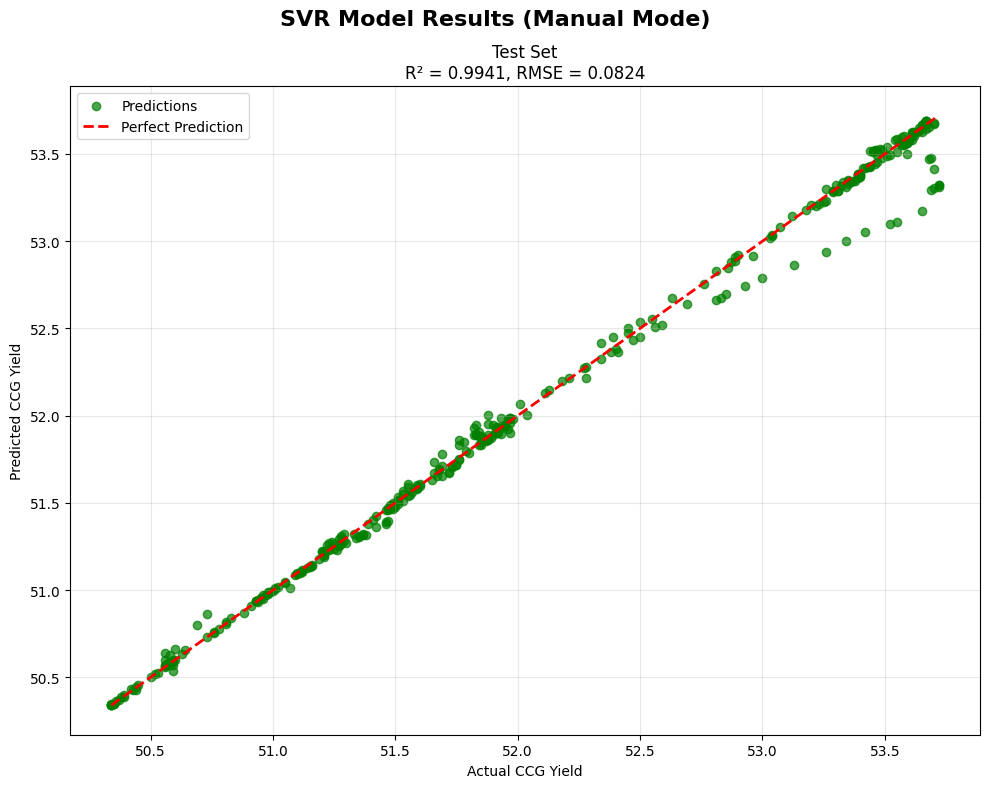

Prediction range: [50.34, 53.69]
Prediction std: 1.05
Unique values: 194


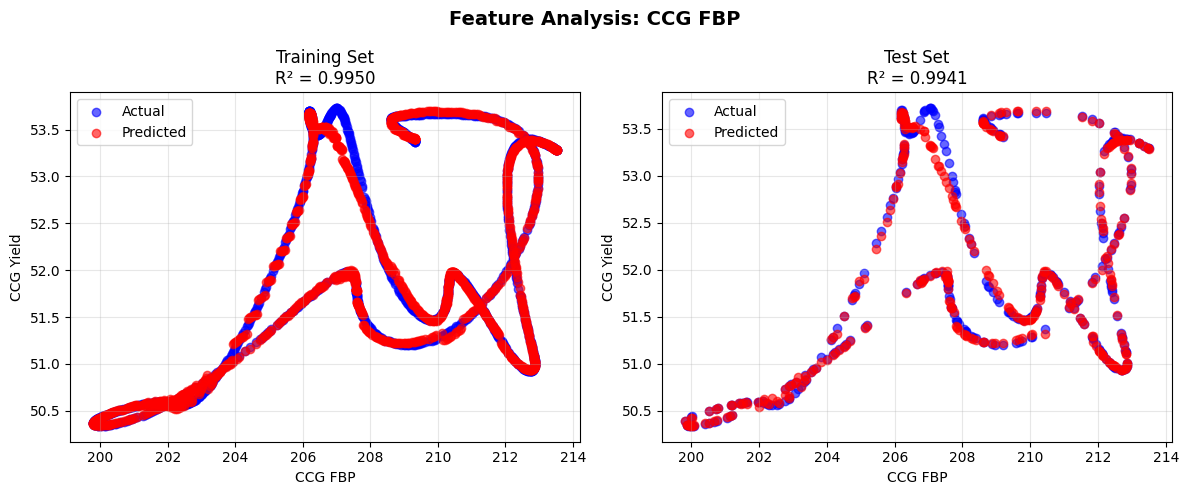

In [10]:
# 1. Load data
svr_model = CompleteSVR()

# df_original_path = r'D:\python-workspace\.venv\Notebooks\dataset_rounded_2f.csv'
# df_denoised_path = r'D:\python-workspace\.venv\Notebooks\alladdedjulycut_cleanminimaxi_denoised.csv'
# df_denoised_path = r'D:\python-workspace\.venv\Notebooks\alladdedjulycut_cleansqtwologhard_denoised.csv'
# df_denoised_path = r'D:\python-workspace\.venv\Notebooks\Gaussian_denoised_aromfix1.csv'
df_denoised_path = r'D:\python-workspace\.venv\Notebooks\Gaussian_denoised50_final.csv'

# 1. โหลดข้อมูลต้นฉบับ
# df_original = pd.read_csv(df_original_path)
# df_denoised = pd.read_csv(df_denoised_path)

# # 2. สร้าง fixed dataset
# df_fixed = df_denoised.copy()
# df_fixed['CCG Yield'] = df_original['CCG Yield']  # ใช้ target เดิม!

# df_fixed.to_csv(r'D:\python-workspace\.venv\Notebooks\dataset_fixed.csv', index=False)
# df_fixed_path = r'D:\python-workspace\.venv\Notebooks\dataset_fixed.csv'
svr_model.load_data(df_denoised_path, 'CCG Yield')

# 2. Explore features
svr_model.show_feature_info()

# 3. Drop unwanted features manually
svr_model.drop_features([
    # 'Date',
    #                       'Conversion %',
# 'Feed Temp',
# 'Cat Cir rate',
# # 'C/O Ratio',
# 'OVHD Temp',
# 'TCR flow',
# 'Atomizer Flow',
# # 'Reactor temp',
# 'Feed flow',
# 'stab reflux',
# # 'stab ovhd temp',
# 'stripping steam',
# 'Dense phase temp',
# 'UOPK',
'Total arom',
'Feed FBP', #ปัญหาเยอะ1
# 'Aniline', #ปัญหาเยอะ2
'Feed density',
# 'CCG FBP'
# 'RI'

                          ])

# 4. Auto-drop highly correlated features
# svr_model.drop_features_by_correlation(threshold=0.3)

# 5. Check final feature set
svr_model.show_feature_info()

# 6. Train model with selected features
# svr_model.train_quick()

# svr_model.train_auto_tuning()

svr_model.train_manual(C=0.5, gamma=0.05, epsilon=0.00001)

svr_model.print_results()

svr_model.plot_results()

svr_model.plot_feature_analysis('CCG FBP')

# svr_model.plot_feature_importance(n_repeats=10)
# svr_model.plot_partial_dependence()
# })

In [11]:
prediction=svr_model.predict_single({
'Feed Temp':188.19,
'C/O Ratio':11.78,
'Reactor temp':505.2,
'Feed flow':799.95,
'Stab ovhd temp':58.32,
'Dense phase temp':622.19,
'CCG FBP': 210.4,
'UOPK': 12.08,
})

print(f'Prediction: {prediction}')

Prediction: 51.78


In [5]:
# # self.y_train_pred = y_train_pred
# # self.y_test_pred = y_test_pred
        

# # เช็คหลัง predict
# y_pred_2f = round(y_test_pred, 2)

# print(f"Prediction range: [{y_pred_2f.min():.2f}, {y_pred_2f.max():.2f}]")
# print(f"Prediction std: {y_pred_2f.std():.2f}")
# print(f"Unique values: {len(np.unique(y_pred_2f))}")

# # ✅ ถ้า std > 0.1 และ unique > 10 = ปกติดี
# # ⚠️ ถ้า std < 0.1 หรือ unique < 5 = ยังมีปัญหา

Prediction range: [50.35, 53.71]
Prediction std: 1.01
Unique values: 198


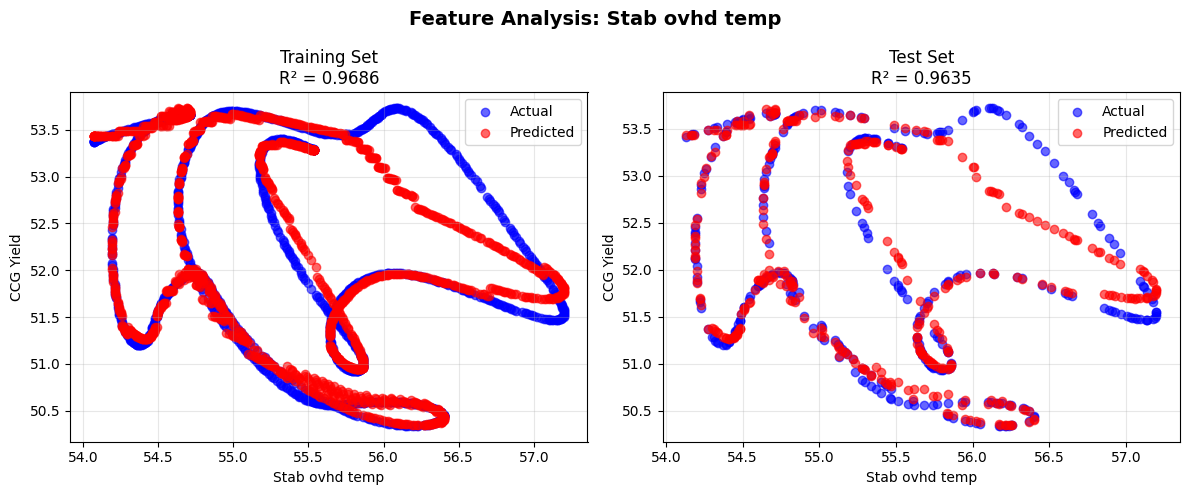

In [6]:
svr_model.plot_feature_analysis('Stab ovhd temp')

In [7]:
import pickle
# Save the model
model_package = {
    'model': svr_model.model,           # The actual trained model (SVR, etc.)
    'scaler_X': svr_model.scaler_X,     # Feature scaler
    'scaler_y': svr_model.scaler_y      # Target scaler
}

# Save as new file
with open('svr_model_package.pkl', 'wb') as f:
    pickle.dump(model_package, f)
    